# Machine-Learning TP M1 IDS
By Kirsley Chennen @ LGM INSERM U1112



# PART 1: Exploration, formating and data split

## The Data that we will use
## [Stroke Prediction Dataset](https://www.kaggle.com/fedesoriano/stroke-prediction-dataset)
### **Context**
According to the World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths.
This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relavant information about the patient.
Attribute Information
### **11 clinical features for predicting stroke events**
1. **id:** unique identifier
2. **gender:** "Male", "Female" or "Other"
3. **age**: age of the patient
4. **hypertension**: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5. **heart_disease**: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6. **ever_married**: "No" or "Yes"
7. **work_type**: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8. **Residence_type**: "Rural" or "Urban"
9. **avg_glucose_level**: average glucose level in blood
10. **bmi**: body mass index
11. **smoking_status**: "formerly smoked", "never smoked", "smokes" or "Unknown"*
12. **stroke**: 1 if the patient had a stroke or 0 if not  
* Note: "Unknown" in smoking_status means that the information is unavailable for this patient

## **Tasks: Data Exploration**
1. Import the data (and set the dataframe index to the ID column)
2. Print the shape of the dataset and the first 5 lines
3. Calculate the ratio stroke/non-stroke  
4. Plot histogram of the "age" column separate by stroke vs non-stroke status.
5. Print the type of each columns (number, object...)

## **Questions:**
1. How many entries (patients) are in the dataset ?
2. How many columns (features) ?
3. Plot the histogram of the age feature. Do separate histogram for stroke vs non-stroke patients
4. What is the percentage of the patients that had a stroke ?
5. Show the type of data in each columns. What type of processing will we have to do for each type ?

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

# Import the data (df variable) using read_csv() and set the index with .set_index()
df = pd.read_csv("https://www.lbgi.fr/~kchennen/healthcare-dataset-stroke-data.csv")

# Print the shape of the dataframe and the head using df.shape and df.head()
print("Shape of df:", df.shape)

# Affichage des 5 premières lignes du DataFrame
print(df.head())

Shape of df: (5110, 12)
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


Proportions des classes 'stroke' :
stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


<Axes: >

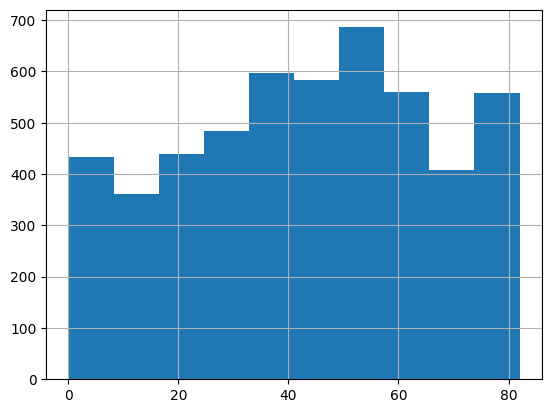

In [4]:
# Use value_counts() on the "stroke" column. Check value_counts parameter to normalize !

stroke_counts = df["stroke"].value_counts(normalize=True)
print("Proportions des classes 'stroke' :")
print(stroke_counts)



# Use pandas built-in dataframe .hist() methods to plot the histo of the "age" column. Check hist parameters to group by !
df["age"].hist(bins=10)

In [ ]:
# Print the "dtypes" attribute of dataframe
print(df.dtypes)

## **Tasks: Data Formating**
You will now do the pre-processing of data.
For each type of object you will have to process them in a usable format for ML algorithm.

## **Questions**
1. What columns are categorical data, what columns are numeric.
2. What columns are already ready to be used and needs no change.
3. What type of processing do you need to do on categorical data and why
4. What type of processing do you need to do on numeric data and why
5. What columns contains missing data ? What type of processing do you need to do in this case.

## **Ressources**:
[Google's Class: Transforming Numeric Data](https://developers.google.com/machine-learning/data-prep/transform/transform-numeric)  
[Google's Class: Transforming Categorical Data](https://developers.google.com/machine-learning/data-prep/transform/transform-categorical)

![Categorial Feature](https://i.imgur.com/mRFk0Sh.png)

In [6]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. Définition des colonnes par type
columns_categorical = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
columns_numeric = ["age", "avg_glucose_level", "bmi"]
columns_nothing = ["hypertension", "heart_disease", "stroke"]

# 2. One-hot encoding des variables catégorielles
enc = OneHotEncoder()
X_cat = df[columns_categorical]
X_cat_onehot = enc.fit_transform(X_cat).toarray()
X_cat_columns_onehot = enc.get_feature_names_out()

# 3. Standardisation des variables numériques
X_num = df[columns_numeric]
X_num_scaled = StandardScaler().fit_transform(X_num)
X_num_columns_scaled = X_num.columns

# 4. Colonnes sans transformation (juste en array)
X_nothing_to_do = df[columns_nothing].to_numpy()

# 5. Fusion de toutes les données
array_data = np.concatenate([X_cat_onehot, X_num_scaled, X_nothing_to_do], axis=1)

# 6. Imputation des données manquantes
imp_mean = IterativeImputer()
array_data = imp_mean.fit_transform(array_data)

# 7. Création d’un DataFrame final pour affichage
df_data = pd.DataFrame(data=array_data, columns=list(X_cat_columns_onehot) + list(X_num_columns_scaled) + columns_nothing)

df_data.head()


,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,...,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age,avg_glucose_level,bmi,hypertension,heart_disease,stroke
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.051434,2.706375,0.981345,0.0,1.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.786070,2.121559,0.289351,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.626390,-0.005028,0.459269,0.0,1.0,1.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.255342,1.437358,0.701207,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.582163,1.501184,-0.623083,1.0,0.0,1.0


## **Tasks: Data Train/Test Spliting**
Now you can split the data between training and testing data.

## **Questions**
1. What train/test ratio should you use.
2. How many entries are in your train dataset and in your test dataset.
3. Verify that you have the same stroke / no-stroke ratio between train and test dataset.

In [8]:
from sklearn.model_selection import train_test_split
import numpy as np

# Séparation des features (X) et de la target (Y = dernière colonne)
X = array_data[:, :-1]
Y = array_data[:, -1]

# Split des données en train/test (80% - 20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Affichage des shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Affichage des ratios (0/1) dans Y_train et Y_test
print("Y_train class distribution:", np.unique(Y_train, return_counts=True))
print("Y_test class distribution:", np.unique(Y_test, return_counts=True))


X_train shape: (4088, 21)
X_test shape: (1022, 21)
Y_train class distribution: (array([0., 1.]), array([3889,  199]))
Y_test class distribution: (array([0., 1.]), array([972,  50]))


# PART 2: Create your machine-learning model

## **Tasks: Choose a model and do basic evaluation**
Select from scikit-learn a model and train it (fit) with the train data. Then calculate the accuracy of the model on the test data. Plot the confusion matrix of the test data classification.

## **Questions:**
1. Which model did you choose and why ? Have you set any particular (hyper)parameters ?
2. What accuracy-score do you get and what conclusion can you take ?
3. What do you observe on the confusion matrix and what conclusion can you take ?

![Accuracy and Confusion Matrix](https://i.imgur.com/EAf5SNh.png)

Accuracy on test set: 0.9510763209393346


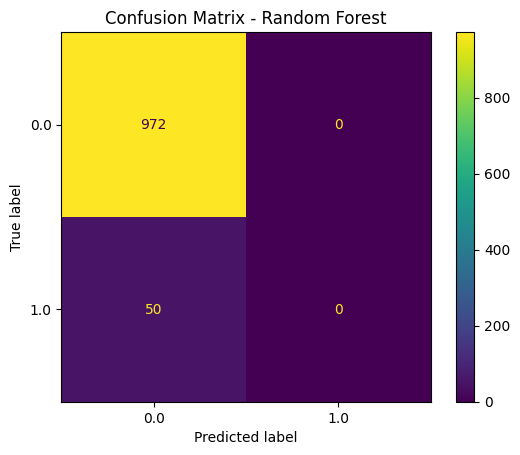

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Création du modèle Random Forest
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Entraînement du modèle
clf.fit(X_train, Y_train)

# Évaluation de la précision sur les données de test
print("Accuracy on test set:", clf.score(X_test, Y_test))

# Affichage de la matrice de confusion (nouvelle méthode)
ConfusionMatrixDisplay.from_estimator(clf, X_test, Y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()


## **Tasks: Correct the previous issue**
You will now try to downsample your majority class to the level of minority class to have a 50/50 ratio and re-do a train/test split.  
Then you will re-train a new model with the new ratio-corrected data and get accuracy+confusion matrix plot.
Don't only predict the class, but also show the prediction probability for all data in the test set !
## **Questions**
1. What accuracy-score do you get with the new model and what conclusion can you take.
2. What do you observe on the confusion matrix and what conclusion can you take.
3. Did you managed to print the probability of each prediction ? What's the shape of the prediction probability output ? Is there a high variance between the different test entries in probability ?

![Downsampling](https://i.imgur.com/QPOuSKk.png)

## Graphical Recap of our data-variable as we are having plenty of them !
### **Here you will be creating variable called X_down, X_down_test..., so you don't get lost with all names, watch this diagram !**
![Variable Diagram](https://i.imgur.com/tShIU1R.png)

Accuracy on downsampled test set: 0.76


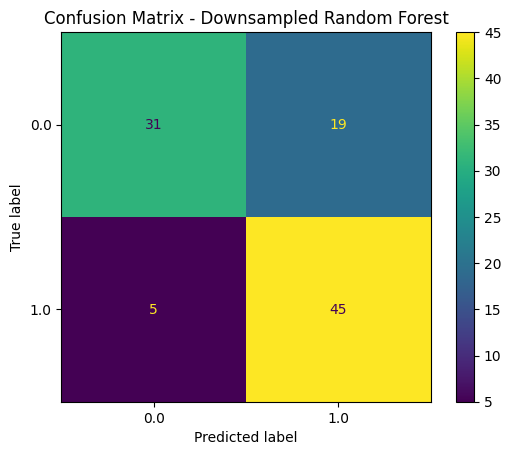

Prediction probabilities for first 10 test samples:
[[0.39367977 0.60632023]
 [0.92381732 0.07618268]
 [0.20791301 0.79208699]
 [0.3237295  0.6762705 ]
 [0.80552114 0.19447886]
 [0.51361516 0.48638484]
 [0.39974556 0.60025444]
 [0.49585713 0.50414287]
 [0.47322845 0.52677155]
 [0.35841348 0.64158652]]


In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

np.random.seed(777)

# Obtenir les index de chaque classe
i_class0 = np.where(Y == 0)[0]
i_class1 = np.where(Y == 1)[0]

# Nombre d'observations dans chaque classe
n_class0 = len(i_class0)
n_class1 = len(i_class1)

# Downsampling de la classe 0 pour équilibrer avec la classe 1
i_class0_downsampled = np.random.choice(i_class0, size=n_class1, replace=False)

# Création des nouveaux X et Y équilibrés
Y_down = np.hstack((Y[i_class0_downsampled], Y[i_class1]))
X_down = np.vstack((X[i_class0_downsampled], X[i_class1]))

# Nouveau split train/test
X_train_down, X_test_down, Y_train_down, Y_test_down = train_test_split(
    X_down, Y_down, test_size=0.2, random_state=42, stratify=Y_down
)

# Modèle sur données downsamplées
clf_down = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf_down.fit(X_train_down, Y_train_down)

# Évaluation
print("Accuracy on downsampled test set:", clf_down.score(X_test_down, Y_test_down))

# Matrice de confusion
ConfusionMatrixDisplay.from_estimator(clf_down, X_test_down, Y_test_down)
plt.title("Confusion Matrix - Downsampled Random Forest")
plt.show()

# Probabilités prédites pour les 10 premiers exemples du test
print("Prediction probabilities for first 10 test samples:")
print(clf_down.predict_proba(X_test_down[:10]))



# PART 3: Evaluate your model

## **Tasks: See all common metrics and evalute both models !**
In this last part you will have to calculate all relevant metrics for a binary classification to compare your two models.  
Make a table containing the results for both models in terms of: accuracy, balance accuracy, F1 Score, sensitivity (recall), specificity, Precision and confusion matrix data (True Pos., True Neg., False Pos., False Neg.)

## **Questions:**
1. Which model have the accuracy ?
2. Which model have the best area under the curve (AUC) for the ROC-curve ?
3. Which model have the best F1-Score and sensitivity ?
4. Eventually, which model is better according to you based on the metrics ?

![Roc Curve](https://i.imgur.com/DFw604d.png)
![F1-Score](https://i.imgur.com/8b5AkS3.png)

,Balanced-Accuracy,Accuracy,F1-Score,Sensitivity (Recall),Specificity,Precision,TP,TN,FP,FN
CLF,0.50,0.951076,0.000000,0.0,1.00,0.000000,0,972,0,50
CLF DownSampled,0.76,0.760000,0.789474,0.9,0.62,0.703125,45,31,19,5


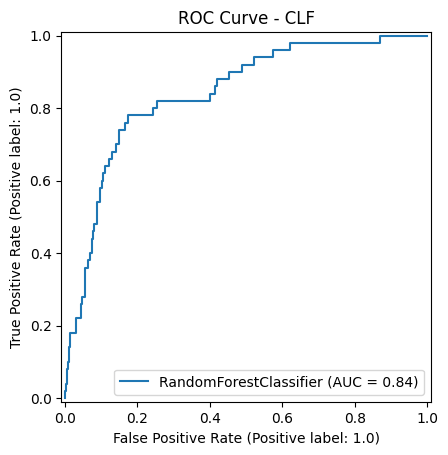

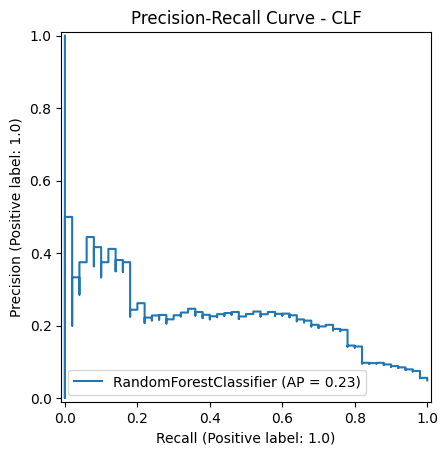

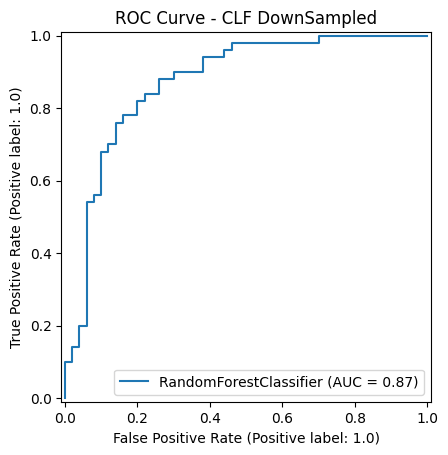

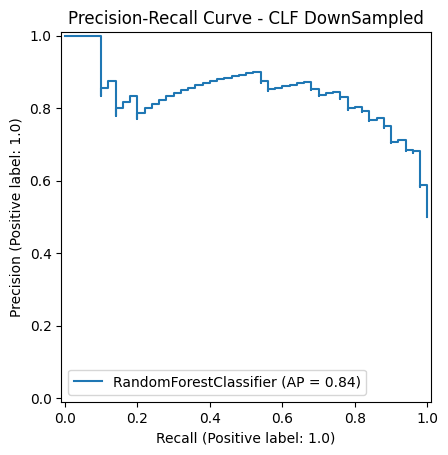

In [13]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

def get_all_metrics(clf, X_test, Y_test):
    """Function that returns all the metrics for a given classifier and test data"""
    # Prédictions
    y_pred = clf.predict(X_test)

    # Matrice de confusion
    tn, fp, fn, tp = confusion_matrix(Y_test, y_pred).ravel()

    # Métriques
    ac = accuracy_score(Y_test, y_pred)
    bac = balanced_accuracy_score(Y_test, y_pred)
    re = recall_score(Y_test, y_pred)
    pr = precision_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    try:
        sp = tn / float(tn + fp)
    except ZeroDivisionError:
        sp = 0

    return [bac, ac, f1, re, sp, pr, tp, tn, fp, fn]

def make_table_clf(clf, clf_down, X_test, Y_test, X_test_down, Y_test_down):
    """Compare deux modèles avec les principales métriques"""
    results = get_all_metrics(clf, X_test, Y_test)
    results_down = get_all_metrics(clf_down, X_test_down, Y_test_down)
    df = pd.DataFrame(
        [results, results_down],
        columns=[
            "Balanced-Accuracy", "Accuracy", "F1-Score", "Sensitivity (Recall)",
            "Specificity", "Precision", "TP", "TN", "FP", "FN"
        ],
        index=["CLF", "CLF DownSampled"]
    )
    return df

# Appel de la fonction et affichage du tableau
df_metrics = make_table_clf(clf, clf_down, X_test, Y_test, X_test_down, Y_test_down)
display(df_metrics)

# Courbes ROC et Precision-Recall pour clf (déséquilibré)
RocCurveDisplay.from_estimator(clf, X_test, Y_test)
plt.title("ROC Curve - CLF")
plt.show()

PrecisionRecallDisplay.from_estimator(clf, X_test, Y_test)
plt.title("Precision-Recall Curve - CLF")
plt.show()

# Courbes ROC et Precision-Recall pour clf_down (équilibré)
RocCurveDisplay.from_estimator(clf_down, X_test_down, Y_test_down)
plt.title("ROC Curve - CLF DownSampled")
plt.show()

PrecisionRecallDisplay.from_estimator(clf_down, X_test_down, Y_test_down)
plt.title("Precision-Recall Curve - CLF DownSampled")
plt.show()


In [15]:
df_metrics = make_table_clf(clf, clf_down, X_test, Y_test, X_test_down, Y_test_down)
display(df_metrics)


,Balanced-Accuracy,Accuracy,F1-Score,Sensitivity (Recall),Specificity,Precision,TP,TN,FP,FN
CLF,0.50,0.951076,0.000000,0.0,1.00,0.000000,0,972,0,50
CLF DownSampled,0.76,0.760000,0.789474,0.9,0.62,0.703125,45,31,19,5


ROC Curve and Prec/Recall Curve Results For Initial Classifier:


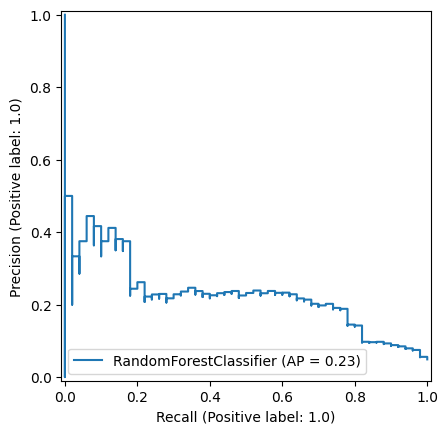

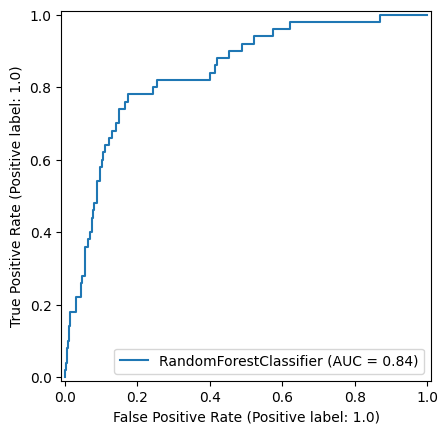

In [16]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

print("ROC Curve and Prec/Recall Curve Results For Initial Classifier:")

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(clf, X_test, Y_test)

# ROC Curve
RocCurveDisplay.from_estimator(clf, X_test, Y_test)

In [17]:
# Do The same as the cell above, but with clf_down model, and X_test_down and Y_test_down data to compare the results !
print("ROC Curve and Prec/Recall Cruve Results For Downsampled Classifier: ")

ROC Curve and Prec/Recall Cruve Results For Downsampled Classifier: 


# BONUS 1: Do Cross-validation instead of simple test/train split.

## **Tasks:**  
Instead of a simple Test/Train split, we will do cross-validation. This means that we will train multiple models with different splits, so that all data have been used for training and all for testing. Then we will average the results of all models.  
For example, if we do a 80/20% train/test split, then we would need to do a 5 fold cross-validation so that each data has been in the test-set at least once.  
Find a way to do "stratified k fold", calculate "cross val score" with scikit and print the mean and standard deviation of the score.
## **Questions:**  
1. What is the point of cross-validation ? Did it increase performance ? If not, what is it useful for ?

![Cross-validation](https://fr.mathworks.com/discovery/cross-validation/_jcr_content/mainParsys/image.adapt.full.medium.jpg/1623131646985.jpg)

In [18]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Création de la validation croisée stratifiée à 5 plis
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calcul du score F1 en validation croisée sur les données d'entraînement downsamplées
cross_scores = cross_val_score(clf_down, X_train_down, Y_train_down, cv=cv, scoring='f1')

# Affichage des résultats
print("F1-scores for each fold:", cross_scores)
print("Mean F1-score:", cross_scores.mean())
print("Standard Deviation:", cross_scores.std())


F1-scores for each fold: [0.79069767 0.75294118 0.75       0.69879518 0.75555556]
Mean F1-score: 0.7495979174335281
Standard Deviation: 0.02938346672839942


# BONUS 2:  Automatic hyper-parameters tuning

## **Tasks:**
We will use optuna to automatically find the best parameters for the chosen ML Algorithm (Random Forest here). We define a number of trials (50), a scoring metrics to maximize (F1 Score) and a parameters space to explore (params_grid).  
In the end we will have a model with the best parameters that have been found and we will compared its metrics to our previous classifier (clf_down) without optimisation.  
Try to tweak the hyper parameters spaces to shrink or expand it. Try to optimize another ML Algorithm.  
## **Questions:**  
1. What are the best parameters detected ? Are your best parameters different from the one of other students ? Why ?
2. Did the metrics improved ? Was the optimisation useful ?

## **Warnings**
This is a pretty long task depending of your computed because the program will train and test 50+ models with differents parameters. Your computer will heat up a bit for a few minutes, so don't run it if you don't want it to happens !

![Hyerparameters Tuning](https://i.imgur.com/3plYcqn.png)

In [ ]:
# If you are using Google Colab, uncomment the next line starting with ! and run the cell to install optuna
# !pip install optuna

In [21]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 15.5 MB/s eta 0:00:00


[I 2025-04-30 07:56:50,120] A new study created in memory with name: no-name-ca43e976-227f-49f7-92f8-f674f1677146


Best trial:
  Score:  0.7878429669740237
  Params: 
    n_estimators: 52
    criterion: entropy
    max_depth: 1
    min_samples_split: 20
    min_samples_leaf: 15
    max_features: None
    bootstrap: True
    oob_score: True
    n_jobs: -1
    class_weight: balanced


,Balanced-Accuracy,Accuracy,F1-Score,Sensitivity (Recall),Specificity,Precision,TP,TN,FP,FN
CLF Down,0.76,0.76,0.789474,0.90,0.62,0.703125,45,31,19,5
CLF Down Optimized,0.75,0.75,0.796748,0.98,0.52,0.671233,49,26,24,1


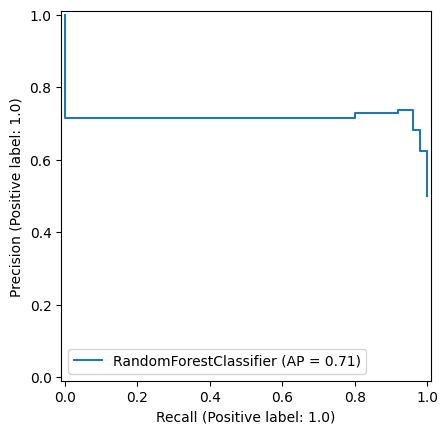

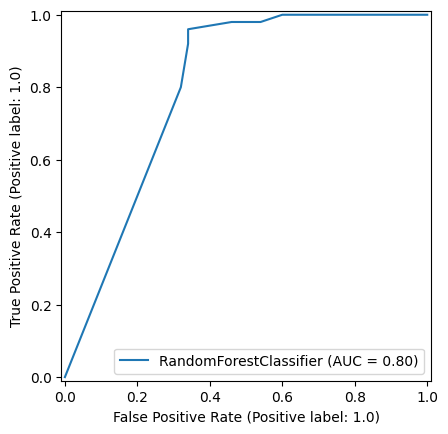

In [22]:
import optuna
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score

def make_table_clf_opti(clf, clf_down, X_test, Y_test, X_test_down, Y_test_down):
	results = get_all_metrics(clf, X_test, Y_test)
	results_down = get_all_metrics(clf_down, X_test_down, Y_test_down)
	df = pd.DataFrame([[i for i in results], [j for j in results_down]], columns=["Balanced-Accuracy", "Accuracy", "F1-Score", "Sensitivity (Recall)", "Specificity", "Precision", "TP"," TN", "FP", "FN"], index=["CLF Down","CLF Down Optimized"])
	return df

def objective_RF(
    trial, est, x_train, Y_train, param_grid, scoring_metric):
    """
    A function that is used by Optuna to get the scoring of a model given the parameters of a specific trial.
    """
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", param_grid["n_estimators"][0], param_grid["n_estimators"][1]
        ),
        "criterion": trial.suggest_categorical("criterion", param_grid["criterion"]),
        "max_depth": trial.suggest_int(
            "max_depth", param_grid["max_depth"][0], param_grid["max_depth"][1]
        ),
        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            param_grid["min_samples_split"][0],
            param_grid["min_samples_split"][1],
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            param_grid["min_samples_leaf"][0],
            param_grid["min_samples_leaf"][1],
        ),
        "max_features": trial.suggest_categorical(
            "max_features", param_grid["max_features"]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", param_grid["bootstrap"]),
        "oob_score": trial.suggest_categorical("oob_score", param_grid["oob_score"]),
        "n_jobs": trial.suggest_categorical("n_jobs", param_grid["n_jobs"]),
        "class_weight": trial.suggest_categorical(
            "class_weight", param_grid["class_weight"]
        ),
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True)
    model = clone(est).set_params(**params)
    performance = np.mean(
        cross_val_score(
            model,
            x_train,
            Y_train,
            cv=cv,
            scoring=scoring_metric,
            error_score="raise",
        )
    )
    return performance

# Random Forest parameters space
param_grid = {'n_estimators': [10,400],
                'criterion' : ['gini', 'entropy'],
                'max_depth' : [1, 15],
                'min_samples_split' : [2, 50],
                'min_samples_leaf' : [1, 50],
                'max_features' : [None, 'auto','log2'],
                'bootstrap' : [True],
                'oob_score' : [False, True],
                'n_jobs' : [-1],
                'class_weight' : [None, 'balanced']}

# Run Hyperparameter Sweep: first we set up some settings.
n_trials = 50
scoring_metric = "f1"
timeout = 300
est = RandomForestClassifier()
sampler = optuna.samplers.TPESampler()
study = optuna.create_study(direction="maximize", sampler=sampler)
optuna.logging.set_verbosity(optuna.logging.CRITICAL)

# We launch the optimization using the previous function as score-returning.
study.optimize(
    lambda trial: objective_RF(
        trial, est, X_train_down, Y_train_down, param_grid, scoring_metric),
    n_trials=n_trials,
    timeout=timeout,
    catch=(ValueError,),
)
# We retrieve the best results now that the optimization is finished.
print("Best trial:")
best_trial = study.best_trial
print("  Score: ", best_trial.value)
print("  Params: ")
for key, value in best_trial.params.items():
    print("    {}: {}".format(key, value))

# Train model using 'best' hyperparameters
est = RandomForestClassifier()
clf = clone(est).set_params(**best_trial.params)

model = clf.fit(X_train_down, Y_train_down)
y_pred = clf.predict(X_test_down)

PrecisionRecallDisplay.from_estimator(model, X_test_down, Y_test_down)
RocCurveDisplay.from_estimator(model, X_test_down, Y_test_down)

make_table_clf_opti(clf_down, model, X_test_down, Y_test_down, X_test_down, Y_test_down)

# Additional Ressources

Google's Class lists and ressources on ML [https://developers.google.com/machine-learning/crash-course](https://developers.google.com/machine-learning/crash-course)  
If you want to become an AI Expert: AI Rodmap [https://i.am.ai/roadmap](https://i.am.ai/roadmap)  
Visualisation in Python [https://www.python-graph-gallery.com/](https://www.python-graph-gallery.com/)  
Public Dataset to create projects [https://github.com/awesomedata/awesome-public-datasets](https://github.com/awesomedata/awesome-public-datasets)  
Machine Learning Competitions with Prize [https://www.kaggle.com/](https://www.kaggle.com/)